# Geometric Grid Stretching #

Conside the subdivision of the interval $x \in [a,b]$ such that successive intervals sizes are related by a multiplier:

$$\Delta x_{i+1} = \alpha\Delta x_i$$

where $\Delta x_i=x_{i+1}-x_i$ is the difference between two successive nodes $s_i$ and $s_{i+1}$. To simplify the process, transform coordinates with $s = \frac{x-a}{b-a}$. The interval of interest is then $s\in[0,1]$ and

$$\Delta s_{i+1} = \alpha\Delta s_i.$$

Specifying the number of intervals as $N$, then

$$s_0 = 0$$
$$s_1 = 0 + \Delta s_0$$
$$s_2 = 0 + \Delta s_0 + \alpha\Delta s_0$$
$$s_n = \sum_{k=0}^{n-1} \alpha^k \Delta s_0$$
$$s_N = \sum_{k=0}^{N-1} \alpha^k \Delta s_0 = 1$$

This approach is called "geometric" because of the presence of the finite geometric series in the formula, which can be used to calculate the nodal values for any $i$, most notably the endpoint (as long as $\alpha\ne 1$):

$$\sum_{k=0}^{N-1} \alpha^k \Delta s_0 = \frac{1-\alpha^{N-1}}{1-\alpha}\Delta s_0, \text{  for }\alpha \ne 1$$

Given an $N$ and $\Delta s_0$, this can be rewritten as a function to be used to solve for $\alpha$:

$$f(\alpha) = 1 - s_N = 1 - \sum_{k=0}^{N-1} \alpha^{k} \Delta s_0 $$
$$f'(\alpha) = - \sum_{k=1}^{N} k\alpha^{k-1} \Delta s_0 $$


In [ ]:
#import math
#import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [47]:
def mod_geometric_sum(a:float, r:float, n:int) -> float:
    return a * (1.0 - r**(n-1)) / (1.0-r)
def f(alpha:float, delta:float=0.001, N:int=10) -> float:
    if alpha == 1.0:
        return 1.0-N*delta
    return 1.0 - mod_geometric_sum(delta, alpha, N)

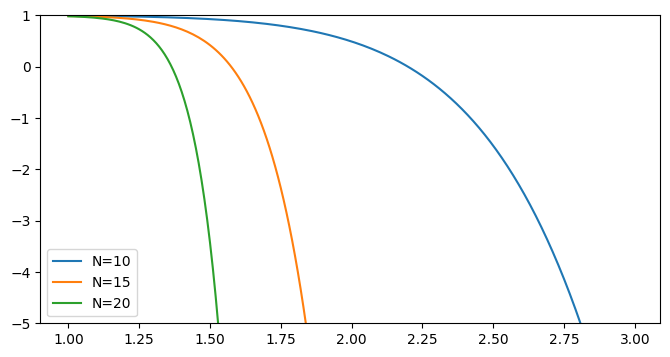

In [55]:
x = np.arange(1.0, 3.0, 0.01)
y = np.arange(1.0, 3.0, 0.01)
for i in range(len(x)):
    y[i] = f(x[i])
fig, ax1 = plt.subplots(1, 1, sharey=False)
fig.set_size_inches(8, 4)
ax1.plot(x, y, label='N=10')
ax1.set_ylim([-5, 1])

for i in range(len(x)):
    y[i] = f(x[i], N=15)
ax1.plot(x, y, label='N=15')

for i in range(len(x)):
    y[i] = f(x[i], N=20)
ax1.plot(x, y, label='N=20')

ax1.legend(loc='lower left');